Create the Top 10 Dataset

In [ ]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Final_Docking_Dataset.xlsx")

top10 = df.nsmallest(10, "Binding Energy (kcal/mol)")

top10

,Ligand,Binding Energy (kcal/mol),PubChem CID,Molecular Weight,XLogP,TPSA,H Bond Donor,H Bond Acceptor,Rotatable Bonds
0,EGCG,-11.972,65064,458.40,1.2,197.0,8,11,4
1,Donepezil,-11.771,3152,379.50,4.3,38.8,0,4,6
2,Demethoxycurcumin,-10.948,5469424,338.40,3.3,83.8,2,5,7
3,Curcumin,-10.932,969516,368.40,3.2,93.1,2,6,8
4,Bisdemethoxycurcumin,-10.749,5315472,308.30,3.3,74.6,2,4,6
5,Hesperidin,-10.739,10621,610.60,-1.1,234.0,8,15,7
6,Rosmarinic acid,-10.675,5281792,360.30,2.4,145.0,5,8,7
7,Baicalein,-10.570,5281605,270.24,1.7,87.0,3,5,1
8,Ellagic acid,-10.447,5281855,302.19,1.1,134.0,4,8,0
9,Chrysin,-10.411,5281607,254.24,2.1,66.8,2,4,1


In [ ]:
top10.to_excel("Top10_Compounds.xlsx", index=False)

Get Canonical SMILES

In [ ]:
!pip install pubchempy

In [ ]:
import pubchempy as pcp

smiles = []

for ligand in top10["Ligand"]:
    try:
        compound = pcp.get_compounds(ligand, "name")[0]
        smiles.append(compound.canonical_smiles)
    except:
        smiles.append(None)

top10["Canonical_SMILES"] = smiles

top10

/tmp/ipykernel_1023/3020284778.py:8: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  smiles.append(compound.canonical_smiles)


,Ligand,Binding Energy (kcal/mol),PubChem CID,Molecular Weight,XLogP,TPSA,H Bond Donor,H Bond Acceptor,Rotatable Bonds,Canonical_SMILES
0,EGCG,-11.972,65064,458.40,1.2,197.0,8,11,4,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C(=C3)O)O)O...
1,Donepezil,-11.771,3152,379.50,4.3,38.8,0,4,6,COC1=C(C=C2C(=C1)CC(C2=O)CC3CCN(CC3)CC4=CC=CC=...
2,Demethoxycurcumin,-10.948,5469424,338.40,3.3,83.8,2,5,7,COC1=C(C=CC(=C1)C=CC(=O)CC(=O)C=CC2=CC=C(C=C2)O)O
3,Curcumin,-10.932,969516,368.40,3.2,93.1,2,6,8,COC1=C(C=CC(=C1)C=CC(=O)CC(=O)C=CC2=CC(=C(C=C2...
4,Bisdemethoxycurcumin,-10.749,5315472,308.30,3.3,74.6,2,4,6,C1=CC(=CC=C1C=CC(=O)CC(=O)C=CC2=CC=C(C=C2)O)O
5,Hesperidin,-10.739,10621,610.60,-1.1,234.0,8,15,7,CC1C(C(C(C(O1)OCC2C(C(C(C(O2)OC3=CC(=C4C(=O)CC...
6,Rosmarinic acid,-10.675,5281792,360.30,2.4,145.0,5,8,7,C1=CC(=C(C=C1CC(C(=O)O)OC(=O)C=CC2=CC(=C(C=C2)...
7,Baicalein,-10.570,5281605,270.24,1.7,87.0,3,5,1,C1=CC=C(C=C1)C2=CC(=O)C3=C(O2)C=C(C(=C3O)O)O
8,Ellagic acid,-10.447,5281855,302.19,1.1,134.0,4,8,0,C1=C2C3=C(C(=C1O)O)OC(=O)C4=CC(=C(C(=C43)OC2=O...
9,Chrysin,-10.411,5281607,254.24,2.1,66.8,2,4,1,C1=CC=C(C=C1)C2=CC(=O)C3=C(C=C(C=C3O2)O)O


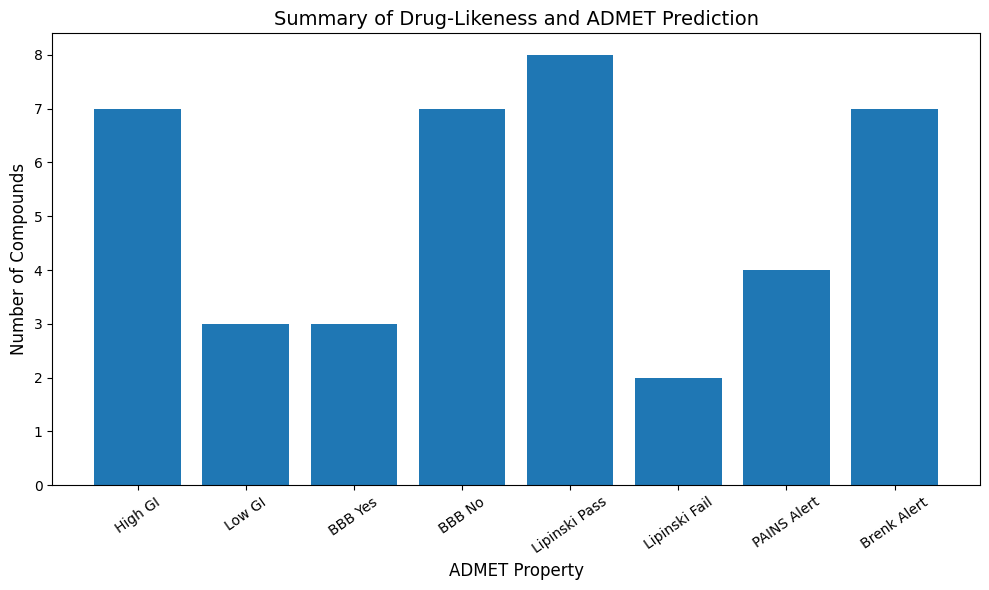

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load ADMET table
df = pd.read_excel("/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/ADMET_Results.xlsx")

# Count properties
gi = df["GI Absorption"].value_counts()
bbb = df["BBB Permeant"].value_counts()

lipinski_pass = (df["Lipinski Violations"] == 0).sum()
lipinski_fail = (df["Lipinski Violations"] > 0).sum()

pains = (df["PAINS Alerts"] > 0).sum()
brenk = (df["Brenk Alerts"] > 0).sum()

# Summary dataframe
summary = pd.DataFrame({
    "Category": [
        "High GI",
        "Low GI",
        "BBB Yes",
        "BBB No",
        "Lipinski Pass",
        "Lipinski Fail",
        "PAINS Alert",
        "Brenk Alert"
    ],
    "Count": [
        gi.get("High",0),
        gi.get("Low",0),
        bbb.get("Yes",0),
        bbb.get("No",0),
        lipinski_pass,
        lipinski_fail,
        pains,
        brenk
    ]
})

plt.figure(figsize=(10,6))

plt.bar(summary["Category"], summary["Count"])

plt.ylabel("Number of Compounds", fontsize=12)
plt.xlabel("ADMET Property", fontsize=12)
plt.title("Summary of Drug-Likeness and ADMET Prediction", fontsize=14)

plt.xticks(rotation=35)

plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Figures/ADMET_Summary.png",
dpi=300,
bbox_inches="tight"
)

plt.show()